In [1]:
import numpy as np
from numpy import random as nprnd
import random as rnd
import pandas as pd
import string as str
from math import *

#scipy stat
import scipy.stats as ss
from scipy import stats
from scipy.stats import linregress,norm, kurtosis, moment,iqr,binom, binomtest,gmean
from scipy.stats import expon,zscore,zmap
from scipy.stats import t,ttest_ind
from scipy.stats import f,f_oneway
from scipy.stats import boxcox
from scipy.stats import pearsonr
#scipy signals library
from scipy import signal
#scipy calculus library
import scipy.integrate as spi



#scipy chi
from scipy.stats import chi,chi2_contingency,chi2

import math

import os
import time

import csv

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.style as style
import seaborn as sns
# Pkg import Date Time
from datetime import datetime
from datetime import timedelta
from pandas.tseries.offsets import Hour, Minute
from pandas.tseries.offsets import Day, MonthEnd
import pytz
from pandas.tseries.frequencies import to_offset
#import arviz as az
import plotly
from sympy import symbols, Eq, solve
import re #extract cofficient

###################################################
'''sklearn'''
###################################################
# # Ordinary Least Squares
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.formula.api import ols
from statsmodels.stats.stattools import durbin_watson
from patsy import dmatrices

from zlib import crc32
import hashlib

###################################################
'''sklearn'''
###################################################
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder,OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.datasets import fetch_openml
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_score
from sklearn.datasets import make_blobs
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import KFold, cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import learning_curve
from sklearn.linear_model import Ridge
from sklearn.linear_model import SGDRegressor

from sklearn.datasets import load_iris

import tensorflow as tf
from tensorflow import keras

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
import tarfile
import urllib.request
import tensorflow as tf
from tensorflow import keras
import sys

# =====================================


### Qus: How to regularized models ?
Reduce overfitting is to regularize the
model (i.e., to constrain it): For example, a simple way to regularize a polynomial model
is to reduce the number of polynomial degrees.
For a linear model, regularization is typically achieved by constraining the weights of
the model.

### Ridge Regression
Ridge Regression (also called Tikhonov regularization) is a regularized version of Linear
Regression.
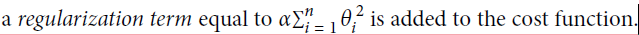

This forces the learning algorithm to not only fit the data but also keep the model
weights as small as possible.

Note that the regularization term should only be added to the cost function during training.

model is trained, you want to evaluate the model’s performance using the unregularized performance measure.


### **Data Set**

In [4]:
np.random.seed(42)
m = 20
X = 3 * np.random.rand(m, 1)
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
X_new = np.linspace(0, 3, 100).reshape(100, 1)

##### Data Set Plot

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(X, y, ".")
plt.xlabel("$x_1$")
plt.ylabel("$y$  ", rotation=0)
plt.axis([0, 3, 0, 3.5])
plt.grid()
plt.show()

### **Ridge Method**

#### Qus: How Linear Regression, perform Ridge Regression ?

By computing a closed-form equation or by performing Gradient Descent. The pros and cons are the
same.

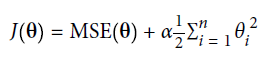

#### Staemodels ridgeregression eqations

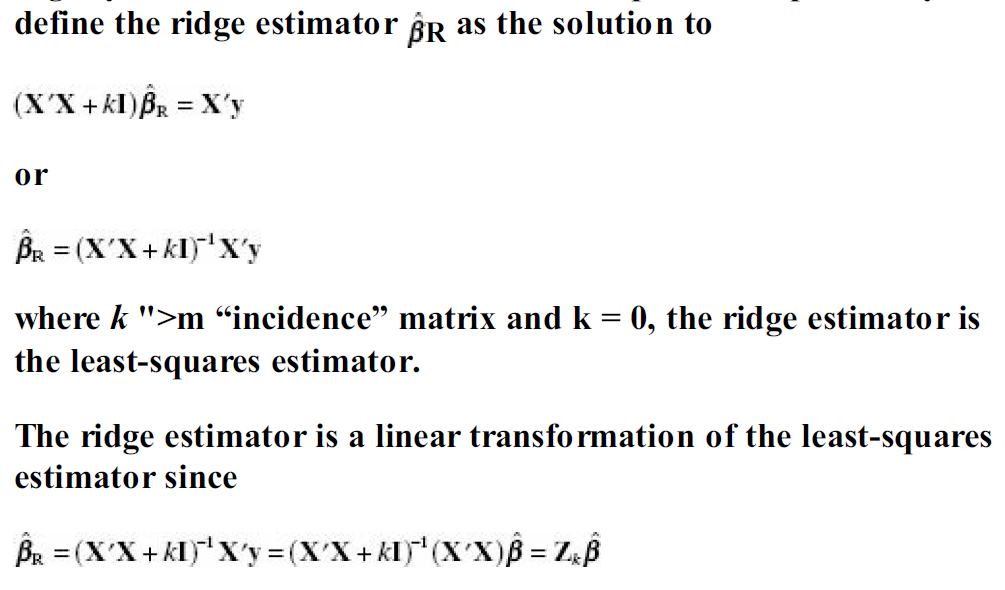

### **α or k:**
hyperparameter α controls how much you want to regularize the model. 
If α = 0 then Ridge Regression is just Linear Regression. 
If α is very large, then all weights end up very close to zero and the result is a flat line going through the data’s mean.

### Ridge Regression cost function

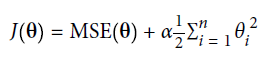

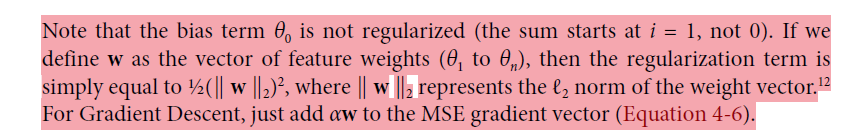

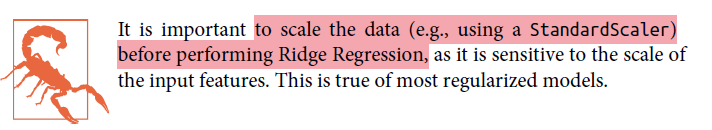



### 1. Ridge regressons in Scikit lern

Note: you can use RidgeCV instade of Ridge. RidgeCV (Ridge regression with built-in cross-validation.)

𝛂 = The penalty weight

#### 1.1 Simpale ridge regressions

#### Note: Ridge Regression closed-form solution
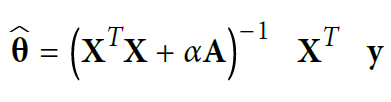

And you can find close form solutions by using solver="cholesky" in ridge method

In [6]:
alpha = [0.1,0.01,1,2] #Given multiuple valie of alpha
for i in alpha:
    ridge_reg = Ridge(alpha=i, solver="cholesky")
    ridge_reg.fit(X, y)
    #ridge_reg.predict([[1.5]])
    print('cofficient @ alpha = ',i,ridge_reg.intercept_,ridge_reg.coef_)


cofficient @ alpha =  0.1 [0.97898394] [[0.3828496]]
cofficient @ alpha =  0.01 [0.9760632] [[0.3849767]]
cofficient @ alpha =  1 [1.00650911] [[0.36280369]]
cofficient @ alpha =  2 [1.03389788] [[0.34285712]]


### 2. Statemodels Ridge Regressions

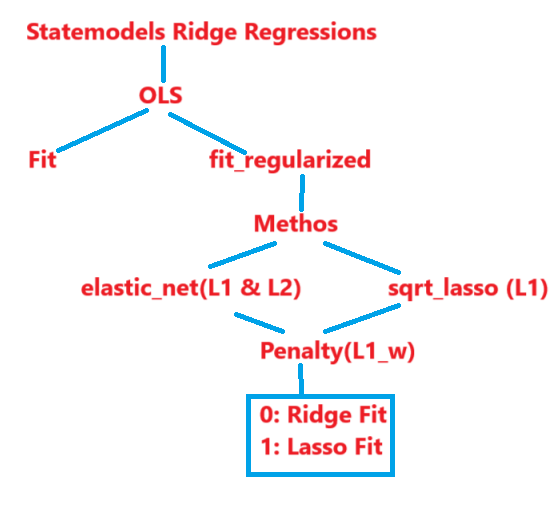

Now alpha argument is different in statemodels.
alpha = scalar or array_like (The penalty weight)

If alpha = scalar i.e. single value
the same penalty weight applies to all variables in the model. 

If alpha =  vector, i.e. array = 1xp matrix 

it must have the same length as params, and contains a penalty weight for each coefficient.

In [ ]:
def norm_scalling(x_array_1d):
    # formula PG113,book Eqn 3.55,3.56
    xij   = x_array_1d
    xjBar = np.mean(xij)
    sjSqr = np.sum(np.square(xij - xjBar))/(np.size(x_array_1d)-1)
    sj = np.sqrt(sjSqr)
    zij = (xij - xjBar)/sj
    #print('sj: ',sj,' xhBar: ',xjBar)
    #print(zij)
    return zij
XX = sm.add_constant(norm_scalling(X))
X_no_scal = sm.add_constant(X)
# Element in alpha should equal to number of regressor
# Scalling just for result match with scikit lern Ridge regressor
penality_for_const = 0.1
penality_for_regressor_x = 0.1
mod = sm.OLS(y, XX)
res = mod.fit_regularized(method='elastic_net',L1_wt=0, alpha=[penality_for_const,penality_for_regressor_x])
print('penality : ',[penality_for_const,penality_for_regressor_x],' cofficient after apply norm scalling: ',res.params)
mod = sm.OLS(y, X_no_scal)
res = mod.fit_regularized(method='elastic_net',L1_wt=0, alpha=[penality_for_const,penality_for_regressor_x],profile_scale=True,refit=True)
print('penality : ',[penality_for_const,penality_for_regressor_x],' cofficient after apply No scalling: ',res.params)

penality :  [0.1, 0.1]  cofficient after apply norm scalling:  [1.3678885  0.32171192]
penality :  [0.1, 0.1]  cofficient after apply No scalling:  [0.79085469 0.4622635 ]


### **Ridge Regressions from Book Method**

See formula above. Fordetails visit book Pg 348 sections 10.5.3

#### 1. Implement formula for Ridge regressions 

API L2_Norm_Ridge_Regressions(data,formulas,alfa)
Use Method:
ridge_coff = L2_Norm_Ridge_Regressions(data = df,
                          formulas = ' y  ~ x1 + x2 + x3 + x1x2 + x1x3 + x2x3 + x1_Sqr + x2_Sqr + x3_Sqr',
                          alfa = 0.128)

Note: Result almose same as scikit lern Ridge method

In [ ]:
def L2_Norm_Ridge_Regressions(data,formulas,alfa):    
    y, X = dmatrices(
                      formula_like = formulas, 
                      data=data,
                      return_type='dataframe'
                    )    
    XdasX = np.dot(np.transpose(X),X)
    ridge_coff_ = np.dot(np.linalg.inv((XdasX + np.identity(XdasX.shape[1])*alfa)),np.dot(np.transpose(X),df['y'].to_numpy()))
    dfRidgeCoff = pd.Series(ridge_coff_)   
    dfRidgeCoff.index = X.columns
    return dfRidgeCoff

#### 2. Not implemented yet
        Need to see all formulas and method form book and apply this manually

### Ridge Regressions by using Linear Regressions follow plynomials + Standard Scaler